# Simple Two-Period Model

- Follows Aiyagari (QJE, 1994) and Davila et al. (ECTA, 2012).
- Continuum (measure 1) of two-period-lived workers/consumers.
- Workers are ex-ante identical: in period 1, each agent is endowed with ω units of output.
- Make consumption/savings decision.
- In $t=2$, random labor endowment: $e_L$ (with probability $\pi$), $e_H > e_L$ (with probability $1-\pi$).
- Law of large numbers: total labor L in period 2 is $\pi e_L + (1−\pi) e_H$.
- Neoclassical production using constant returns to scale production function in period 2. Prices r (return on savings) and w (wages).
- No insurance markets: just precautionary savings with capital.

In [1]:
# Packages we are going to use in this notebook
using Roots
using Plots

## Households

They solve the following maximization problem:
$$
\max_{a} u(c_1) + \beta \mathbb{E}[u(c_2)]
$$

subject to,
$$
c_1 + a = \omega \\
c_{2,L} = R a + w e_L,\\
c_{2,H} = R a + w e_H,
$$

where $\beta \in (0,1]$ is the discount factor, $R \equiv 1 + r$, and $a \in \mathcal{A}$. Additionally, households have constant relative risk aversion (CRRA) utility function,

$$
u(c_t) = \frac{c^{1-\xi}-1}{1-\xi}
$$


Expected utility in period 2 is just the weighted average of each of the outcomes,
$$
\mathbb{E}[u(c_2)] = \pi u(c_{2,L}) + (1 - \pi) u(c_{2,H})
$$



In [2]:
## Household Parameters
β = 0.95
π = 0.5
ξ = 4.0
ω = 0.5

## Labor endowment 
e_L = 0.8
e_H = 1.2


1.2

Households' maximization problem yields the following first order conditions:
$$
u'(c1) = \beta R \mathbb{E}[u'(c2)]
$$

This is the household's Euler equation. With CRRA utility function this is equivalent to,

$$
c_1^{-\xi} = \beta R \mathbb{E}\left[c_2^{-\xi}\right]
$$

and substituting consumption using the budget constrain, we see that the optimal amount of savings $a^*$ (given price $w$ and $R$) is determined as the root that solves the following equation,

$$
(\omega - a^*)^{-\xi} = \beta R [\pi (R*a^* + w * e_L)^{-\xi} + (1-\pi) (R*a^* + w * e_L)^{-\xi}]
$$

In [3]:
## Household
# CRRA utility function
util(c) = (c .^ (1.0 .- ξ) .- 1.0) ./ (1.0 .- ξ)
mutil(c) = c .^ (-ξ)

# Euler equation:
Savings(a) = mutil(ω - a) - β * R * (π * mutil(R*a + w * e_L) + (1-π) * mutil(R*a + w * e_H))

# Since now we are only solving the household's problem (i.e. we are in partial equilibrium) we just take prices as given
# Some initial guesses can be,
w = 0.5
R = 1.02

# We can use the Roots package to find the root of the Euler equation using the find_zero function
lower_bound = -(w/R)*e_L # Natural borrowing limit
upper_bound = ω
Astar = find_zero(Savings, (lower_bound, upper_bound))

0.01982843430478168

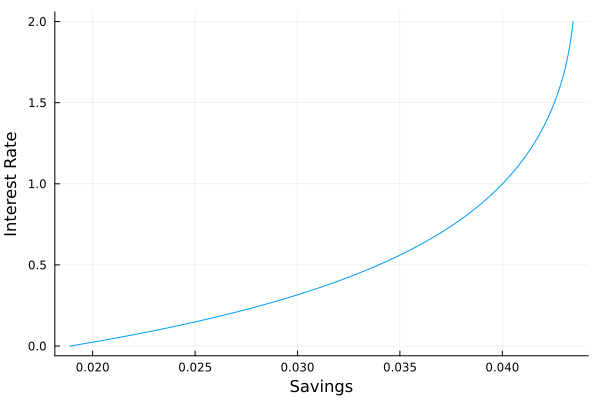

In [4]:
# We can also take a look how does savings change with respect to the interest rate
interest_rates = 0.0:0.01:2.0

Supply = zeros(size(collect(interest_rates)))
for i in eachindex(interest_rates)
      Savings(a) = mutil(ω - a) - β * R * (π * mutil(R*a + w * e_L) + (1-π) * mutil(R*a + w * e_H))
      R = 1.0 + interest_rates[i]
      w = 0.5
      lb = -(w/R)*e_L # Natural borrowing limit
      ub = ω
      Astar = find_zero(Savings, (lb, ub))
      Supply[i] = Astar
end

fig1 = plot(Supply,interest_rates,label=nothing)
xlabel!("Savings")
ylabel!("Interest Rate")
display(fig1)

## Firms

In $t=2$, output is produced by a representative firm with constant returns to scale technology $F(K,L)$.

Hence, firms rent capital (K) and labor (L) from worker households.

The firm's maximization problem is given by,
$$
\max_{K,L} Profits = F(K,L) - RK - wL
$$

which results in the marginal factor pricing,
$$
R = F_K (K,L) \\
w = F_L (K,L)
$$

and in equilibrium profits are zero.

Usually, we use a Cobb-Douglas production function $F(K,L) = K^{\alpha} L^{1-\alpha}$. Therefore, prices are defined as,
$$
R = \alpha K^{\alpha - 1} L^{1 - \alpha} \\
w = (1-\alpha) K^{\alpha} L^{- \alpha}
$$


In [5]:
# Firm Parameters
α = 0.25

0.25

In [6]:
## Firm
L = π * e_L + (1-π) * e_H

F(K) = K^m_par.α * L^(1-m_par.α)
rate(K) = α * K^(α-1) * L^(1-α)
wage(K) = (1-α) * K^α * L^(-α)

wage (generic function with 1 method)


Additionally, we can obtain firm's demand of capital given the return $R$ by solving $R = F_K (K,L)$ for K. In the case of Cobb-Douglas production function this is given by,
$$
K^D(R) = L \times \left(\frac{\alpha}{R}\right)^{\frac{1}{1-\alpha}}
$$


In [7]:
Kdemand(R) = L * (α / R) .^ (1 / (1 - α))

Kdemand (generic function with 1 method)

we can see how the demand for capital changes with respect to the interest rate

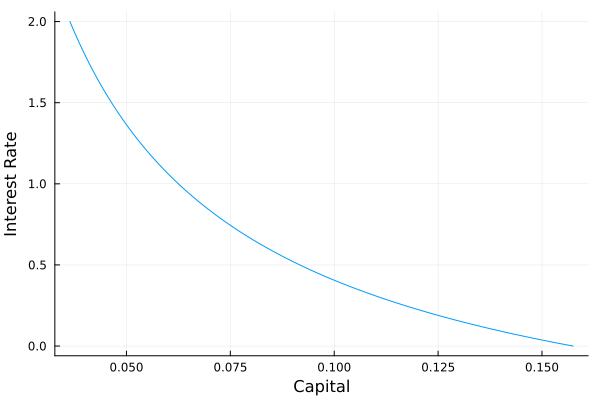

In [8]:
Demand = Kdemand.(1.0 .+ interest_rates)

fig2 = plot(Demand,interest_rates,label=nothing)
xlabel!("Capital")
ylabel!("Interest Rate")
display(fig2)

and combining with the supply of capital (i.e. savings) that come from households we can see the equilibrium

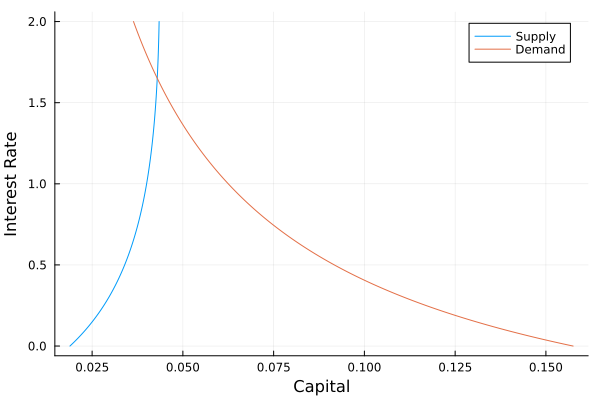

In [9]:
fig3 = plot(Supply,interest_rates,label="Supply") # Remember the supply of capital comes from households' savings
plot!(Demand,interest_rates,label="Demand")
xlabel!("Capital")
ylabel!("Interest Rate")
display(fig3)

## Equilibrium

Therefore, we can obtain the equilibrium by finding where demand for capital meets supply. This will give us the price $r$ and $w$ that clear all markets.

In [10]:
ExcessDemand(0.05)


UndefVarError: UndefVarError: `ExcessDemand` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [11]:
function Ksupply(R,w,ω,β,π,e_L,e_H)
    Savings(a) = mutil(ω - a) - β * R * (π * mutil(R*a + w * e_L) + (1-π) * mutil(R*a + w * e_H))
    lb = -(w/R)*e_L # Natural borrowing limit
    ub = ω
    Astar = find_zero(Savings, (lb, ub))
    return Astar
end

Ksupply (generic function with 1 method)

In [12]:
K = 0.025
K_supply(rate(K),wage(K),ω,β,π,e_L,e_H)

UndefVarError: UndefVarError: `K_supply` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [13]:

K_equilibrium = find_zero(ExcessDemand, (0.02, 0.1))

UndefVarError: UndefVarError: `ExcessDemand` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [14]:
## Equilibrium
function Ksupply(R,w,ω,β,π,e_L,e_H)
    Savings(a) = mutil(ω - a) - β * R * (π * mutil(R*a + w * e_L) + (1-π) * mutil(R*a + w * e_H))
    lb = -(w/R)*e_L # Natural borrowing limit
    ub = ω
    Astar = find_zero(Savings, (lb, ub))
    return Astar
end

ExcessDemand(K) = Ksupply(rate(K),wage(K),ω,β,π,e_L,e_H) - Kdemand(rate(K))

K_equilibrium = find_zero(ExcessDemand, (0.02, 0.1))

R_star = rate(K_equilibrium)
print("R_star: ", R_star, "\n")
w_star = wage(K_equilibrium)
print("w_star: ", w_star, "\n")
Kdemand_star = Kdemand(R_star)
print("K Supply: ", K_equilibrium, "\n")
print("K Demand: ", Kdemand_star, "\n")
print("are equal in equilibrium a_star = K_star")

R_star: 1.8039832347175875
w_star: 0.38811798434236444
K Supply: 0.07171500208964417
K Demand: 0.07171500208964417
are equal in equilibrium a_star = K_star

Consider a case in which households become more patient. How do savings change? What happens to the interest rate and wage in this economy?

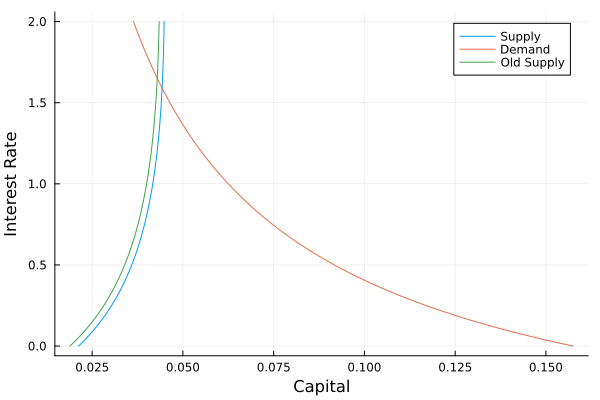

R_star_new: 1.7811324556525538
compared to old R_star: 1.8039832347175875
w_star: 0.3897707042789698
compared to old w_star: 0.38811798434236444


In [15]:
# Households become more patient which means they discount the future less (β increases)
β = 0.99

# We can also take a look how does savings change with respect to the interest rate
interest_rates = 0.0:0.01:2.0

Supply_patient = zeros(size(collect(interest_rates)))
for i in eachindex(interest_rates)
      Savings(a) = mutil(ω - a) - β * R * (π * mutil(R*a + w * e_L) + (1-π) * mutil(R*a + w * e_H))
      R = 1.0 + interest_rates[i]
      w = 0.5
      lb = -(w/R)*e_L # Natural borrowing limit
      ub = ω
      Astar = find_zero(Savings, (lb, ub))
      Supply_patient[i] = Astar
end

fig4 = plot(Supply_patient,interest_rates,label="Supply") # Remember the supply of capital comes from households' savings
plot!(Demand,interest_rates,label="Demand")
plot!(Supply,interest_rates,label="Old Supply")
xlabel!("Capital")
ylabel!("Interest Rate")
display(fig4)

## Equilibrium
K_equilibrium = find_zero(ExcessDemand, (0.01, 0.08))

R_star_new = rate(K_equilibrium)
print("R_star_new: ", R_star_new, "\n")
print("compared to old R_star: ", R_star, "\n")
w_star_new = wage(K_equilibrium)
print("w_star: ", w_star_new, "\n")
print("compared to old w_star: ", w_star, "\n")

What happens if the risk of being in the poor income state in period two increases? Again, how do savings, interest rate and wages change?

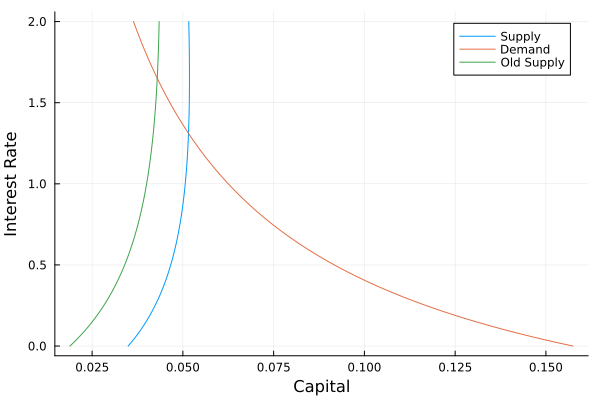

R_star_new: 1.6771185196455145
compared to old R_star: 1.8039832347175875
w_star: 0.3897707042789698
compared to old w_star: 0.38811798434236444


In [16]:
# Households become more patient which means they discount the future less (β increases)
β = 0.95
π = 0.75

# We can also take a look how does savings change with respect to the interest rate
interest_rates = 0.0:0.01:2.0

Supply_risky = zeros(size(collect(interest_rates)))
for i in eachindex(interest_rates)
      Savings(a) = mutil(ω - a) - β * R * (π * mutil(R*a + w * e_L) + (1-π) * mutil(R*a + w * e_H))
      R = 1.0 + interest_rates[i]
      w = 0.5
      lb = -(w/R)*e_L # Natural borrowing limit
      ub = ω
      Astar = find_zero(Savings, (lb, ub))
      Supply_risky[i] = Astar
end

fig5 = plot(Supply_risky,interest_rates,label="Supply") # Remember the supply of capital comes from households' savings
plot!(Demand,interest_rates,label="Demand")
plot!(Supply,interest_rates,label="Old Supply")
xlabel!("Capital")
ylabel!("Interest Rate")
display(fig5)

## Equilibrium
K_equilibrium = find_zero(ExcessDemand, (0.01, 0.08))

R_star_new = rate(K_equilibrium)
print("R_star_new: ", R_star_new, "\n")
print("compared to old R_star: ", R_star, "\n")
print("w_star: ", w_star_new, "\n")
print("compared to old w_star: ", w_star, "\n")